## Imports

In [675]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sps
from IPython.display import display, Latex, Markdown

from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV, cross_val_score
from mixed_naive_bayes import MixedNB

## Data Exploration

### Read Dataset

In [676]:
df = pd.read_csv('generative_ai_misinformation_dataset.csv')

### Dataframe Shape

In [677]:
df.shape

(500, 31)

### Dataframe Analysis

In [678]:
df.head()

,id,post_id,platform,timestamp,date,time,month,weekday,country,city,...,sentiment_score,toxicity_score,model_signature,detected_synthetic_score,embedding_sim_to_facts,factcheck_verdict,external_factchecks_count,source_domain_reliability,engagement,is_misinformation
0,1,P0001,Reddit,2024-03-06 10:01:00,2024-03-06,10:01:00,March,Wednesday,USA,New York,...,-0.223,0.271,GPT-like,0.829,0.357,TRUE,4,0.543,3899,1
1,2,P0002,Reddit,2025-08-07 18:30:00,2025-08-07,18:30:00,August,Thursday,Germany,Berlin,...,-0.718,0.802,GPT-like,0.075,0.987,FALSE,3,0.199,7651,0
2,3,P0003,Telegram,2024-12-13 03:15:00,2024-12-13,03:15:00,December,Friday,USA,New York,...,-0.989,0.815,GPT-like,0.707,0.729,PARTLY,0,0.074,7260,0
3,4,P0004,Twitter,2024-04-05 07:10:00,2024-04-05,07:10:00,April,Friday,USA,Chicago,...,-0.283,0.116,human,0.863,0.623,FALSE,2,0.064,7454,1
4,5,P0005,Telegram,2024-06-07 06:18:00,2024-06-07,06:18:00,June,Friday,Germany,Hamburg,...,-0.378,0.325,GPT-like,0.730,0.638,PARTLY,0,0.472,8320,0


There are 500 samples with 30 columns and 1 target label ```is_misinformation```. Some columns are not really features, for example the two ID columns. The timestamp of the post is included, and so are some derived columns like ```date```, ```time```, ```month```, and ```weekday```. There are columms containing information about the post author and a substantial number of columns about the post content. There are some raw features like ```text_length```, ```num_urls```, etc. However, there are also a fair few processed features such as ```readability_score```, ```sentiment_score```, etc.

Numerical variables: ```author_followers```, ```text_length```, ```token_count```, ```readability_score```, ```num_urls```, ```num_mentions```, ```num_hashtags```, ```sentiment_score```, ```toxicity_score```, ```detected_synthetic_score```, ```embedding_sim_to_facts```, ```external_factchecks_count```, ```source_domain_reliability```, ```engagement```

Categorical variables: ```platform```, ```month```, ```weekday```, ```country```, ```city```, ```timezone```, ```author_verified```, ```model_signature```, ```factcheck_verdict```, ```is_misinformation```

Other variables: ```id```, ```post_id```, ```timestamp```, ```date```, ```time```, ```author_id```, ```text```

### Class Counts

In [679]:
df['is_misinformation'].value_counts()

is_misinformation
1    268
0    232
Name: count, dtype: int64

### Missing Value Counts

In [680]:
df.isna().sum().rename('Missing Value Count')

id                           0
post_id                      0
platform                     0
timestamp                    0
date                         0
time                         0
month                        0
weekday                      0
country                      0
city                         0
timezone                     0
author_id                    0
author_followers             0
author_verified              0
text                         0
text_length                  0
token_count                  0
readability_score            0
num_urls                     0
num_mentions                 0
num_hashtags                 0
sentiment_score              0
toxicity_score               0
model_signature              0
detected_synthetic_score     0
embedding_sim_to_facts       0
factcheck_verdict            0
external_factchecks_count    0
source_domain_reliability    0
engagement                   0
is_misinformation            0
Name: Missing Value Count, dtype: int64

### Histograms

array([[<Axes: title={'center': 'author_followers'}>,
        <Axes: title={'center': 'text_length'}>,
        <Axes: title={'center': 'token_count'}>,
        <Axes: title={'center': 'readability_score'}>],
       [<Axes: title={'center': 'num_urls'}>,
        <Axes: title={'center': 'num_mentions'}>,
        <Axes: title={'center': 'num_hashtags'}>,
        <Axes: title={'center': 'sentiment_score'}>],
       [<Axes: title={'center': 'toxicity_score'}>,
        <Axes: title={'center': 'detected_synthetic_score'}>,
        <Axes: title={'center': 'embedding_sim_to_facts'}>,
        <Axes: title={'center': 'external_factchecks_count'}>],
       [<Axes: title={'center': 'source_domain_reliability'}>,
        <Axes: title={'center': 'engagement'}>, <Axes: >, <Axes: >]],
      dtype=object)

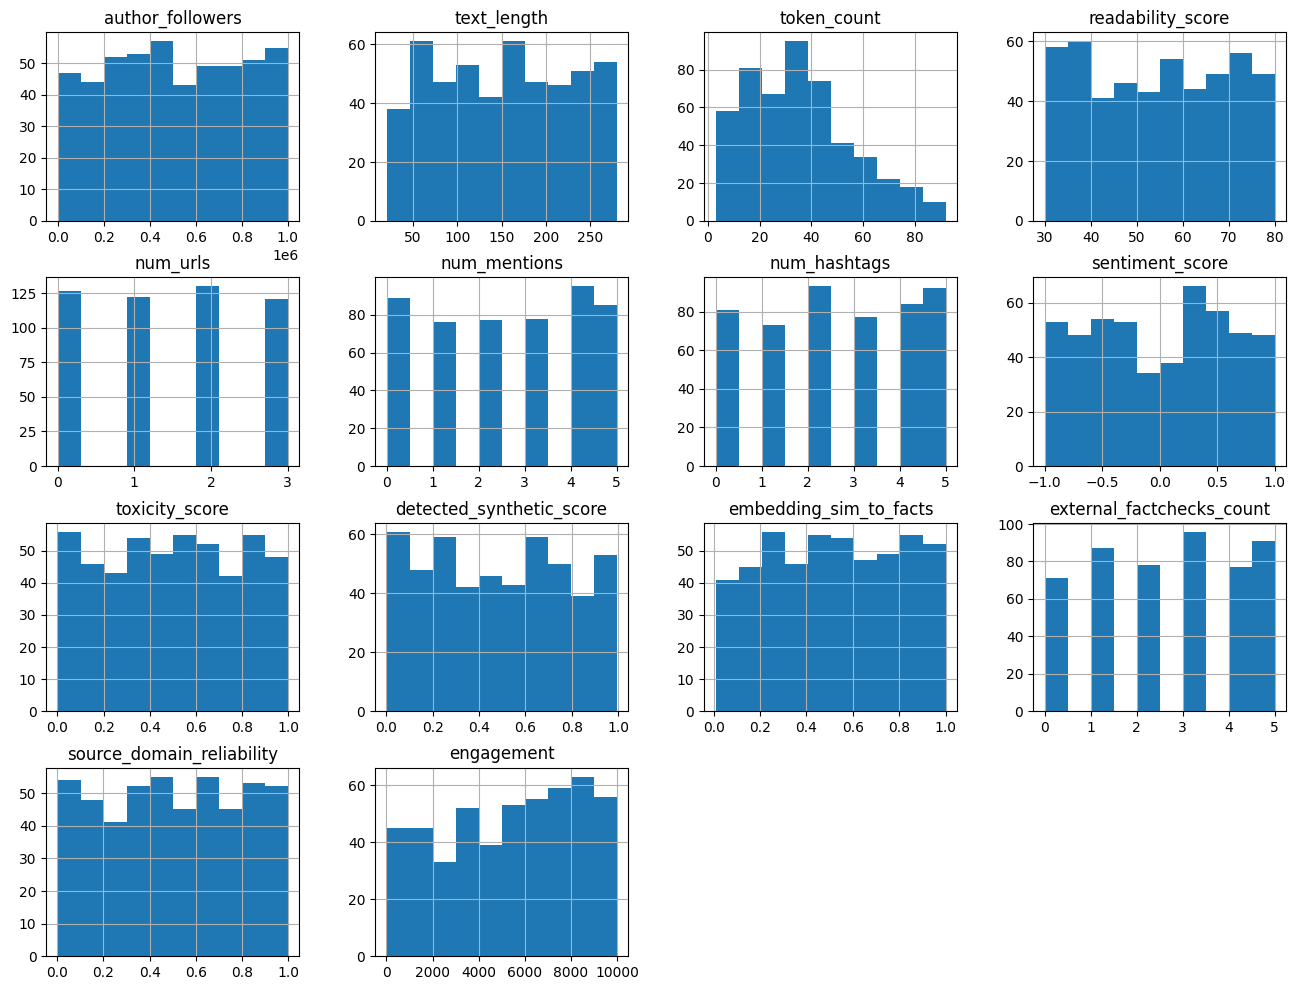

In [681]:
numeric_cols = ['author_followers', 'text_length', 'token_count', 'readability_score', 'num_urls', 'num_mentions', 'num_hashtags', 'sentiment_score', 'toxicity_score', 'detected_synthetic_score', 'embedding_sim_to_facts', 'external_factchecks_count', 'source_domain_reliability', 'engagement']
df[numeric_cols].hist(figsize = (16, 12))

## Feature Learning

### Get Year, Day of Month, Hour From Timestamp

In [682]:
df_processed = df
df_processed['timestamp'] = pd.to_datetime(df['timestamp'])
df_processed['year'] = df_processed['timestamp'].dt.year
df_processed['day_of_month'] = df_processed['timestamp'].dt.day
df_processed['hour'] = df_processed['timestamp'].dt.hour
df_processed[['year', 'day_of_month', 'hour']].head()

numeric_cols += ['year', 'day_of_month', 'hour']

## Pre-processing

### Remove Unneeded Columns

In [683]:
df_processed = df_processed.drop(['id', 'post_id', 'timestamp', 'date', 'time', 'author_id', 'text'], axis = 1)

### One-hot Encoding of Nominal Data

In [684]:
nominal_cols = ['platform', 'month', 'weekday', 'country', 'city', 'timezone', 'model_signature']
df_processed = pd.get_dummies(df_processed, columns = nominal_cols, dtype = np.int64)
df_processed.head()

,author_followers,author_verified,text_length,token_count,readability_score,num_urls,num_mentions,num_hashtags,sentiment_score,toxicity_score,...,city_Rio de Janeiro,city_Sao Paulo,timezone_BRT,timezone_CET,timezone_EST,timezone_GMT,timezone_IST,model_signature_GPT-like,model_signature_human,model_signature_unknown
0,74491,0,137,34,44.05,1,0,0,-0.223,0.271,...,0,0,0,0,1,0,0,1,0,0
1,199709,0,144,24,68.61,0,5,3,-0.718,0.802,...,0,0,0,1,0,0,0,1,0,0
2,470455,0,118,29,68.56,3,1,2,-0.989,0.815,...,0,0,0,0,1,0,0,1,0,0
3,224180,1,228,38,46.54,0,1,3,-0.283,0.116,...,0,0,0,0,1,0,0,0,1,0
4,63968,1,131,43,74.36,0,0,4,-0.378,0.325,...,0,0,0,1,0,0,0,1,0,0


### Label Encoding of Ordinal Data

In [685]:
df_processed['factcheck_verdict'].unique()

array(['TRUE', 'FALSE', 'PARTLY', 'UNVERIFIED'], dtype=object)

In [686]:
df_processed['factcheck_verdict'] = df_processed['factcheck_verdict'].apply(lambda verdict: 3 if verdict == 'TRUE' else 2 if verdict == 'PARTLY' else 1 if verdict == 'FALSE' else 0)

### Correlation Heatmap Across Features

<Axes: >

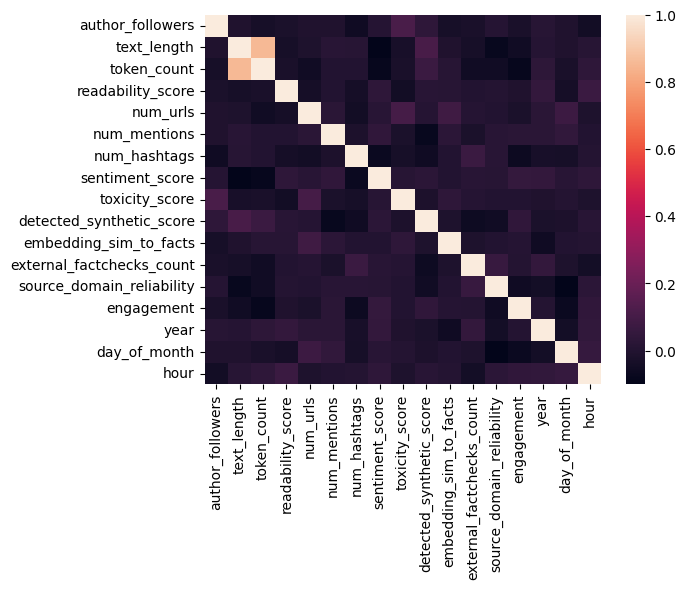

In [687]:
sns.heatmap(df_processed[numeric_cols].corr())

### Remove Columns with High Correlation

In [688]:
df_processed = df_processed.drop('token_count', axis = 1)
numeric_cols.remove('token_count')

### Final Processed Dataframe

In [689]:
df_processed.head()

,author_followers,author_verified,text_length,readability_score,num_urls,num_mentions,num_hashtags,sentiment_score,toxicity_score,detected_synthetic_score,...,city_Rio de Janeiro,city_Sao Paulo,timezone_BRT,timezone_CET,timezone_EST,timezone_GMT,timezone_IST,model_signature_GPT-like,model_signature_human,model_signature_unknown
0,74491,0,137,44.05,1,0,0,-0.223,0.271,0.829,...,0,0,0,0,1,0,0,1,0,0
1,199709,0,144,68.61,0,5,3,-0.718,0.802,0.075,...,0,0,0,1,0,0,0,1,0,0
2,470455,0,118,68.56,3,1,2,-0.989,0.815,0.707,...,0,0,0,0,1,0,0,1,0,0
3,224180,1,228,46.54,0,1,3,-0.283,0.116,0.863,...,0,0,0,0,1,0,0,0,1,0
4,63968,1,131,74.36,0,0,4,-0.378,0.325,0.730,...,0,0,0,1,0,0,0,1,0,0


## Model 1: Support Vector Machine (SVM)

### _Note: verify that there is no data leakage_

In [690]:
X = df_processed.drop('is_misinformation', axis = 1)
y = df_processed['is_misinformation']

svm = SVC(
    shrinking = False,
    probability = False,
    tol = 1e-3,
    cache_size = 200,
    class_weight = None,
    max_iter = -1
)

pipeline = Pipeline(steps = [('standardization', StandardScaler()), ('svm', svm)])

params = [{'svm__C': [1, 10], 'svm__kernel': ['linear']},
          {'svm__C': [1, 10, 100, 1000], 'svm__kernel': ['rbf'], 'svm__gamma': [0.1, 0.01, 0.001, 0.0001]}]
clf = GridSearchCV(
    estimator = pipeline,
    param_grid = params,
    scoring = 'accuracy',
    cv = 5,
)

cv = KFold(n_splits = 5, shuffle = True, random_state = 42)
scores = []
for train, test in cv.split(X):
    clf.fit(X.iloc[train], y.iloc[train])
    scores.append(clf.score(X.iloc[test], y.iloc[test]))

    print(clf.predict(X.iloc[test]))
    print(scores[-1])
    print(clf.best_params_)

print(f'Accuracy: {np.mean(scores)}')

# scores = cross_val_score(
#     estimator = clf,
#     X = X, 
#     y = y,
#     scoring = 'accuracy',
#     cv = 5,
#     # n_jobs = -1,
# )
# print(f'Accuracy: {scores.mean()}')

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
0.55
{'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
0.58
{'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
0.48
{'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
[1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
0.56

## Model 2: Naive Bayes Classifier

### Map Numerical Features to Gaussian Distribution Using Yeo-Johnson Transformation
### _Note: This currently has data leakage_

array([[<Axes: title={'center': 'author_followers'}>,
        <Axes: title={'center': 'text_length'}>,
        <Axes: title={'center': 'readability_score'}>,
        <Axes: title={'center': 'num_urls'}>],
       [<Axes: title={'center': 'num_mentions'}>,
        <Axes: title={'center': 'num_hashtags'}>,
        <Axes: title={'center': 'sentiment_score'}>,
        <Axes: title={'center': 'toxicity_score'}>],
       [<Axes: title={'center': 'detected_synthetic_score'}>,
        <Axes: title={'center': 'embedding_sim_to_facts'}>,
        <Axes: title={'center': 'external_factchecks_count'}>,
        <Axes: title={'center': 'source_domain_reliability'}>],
       [<Axes: title={'center': 'engagement'}>,
        <Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'day_of_month'}>,
        <Axes: title={'center': 'hour'}>]], dtype=object)

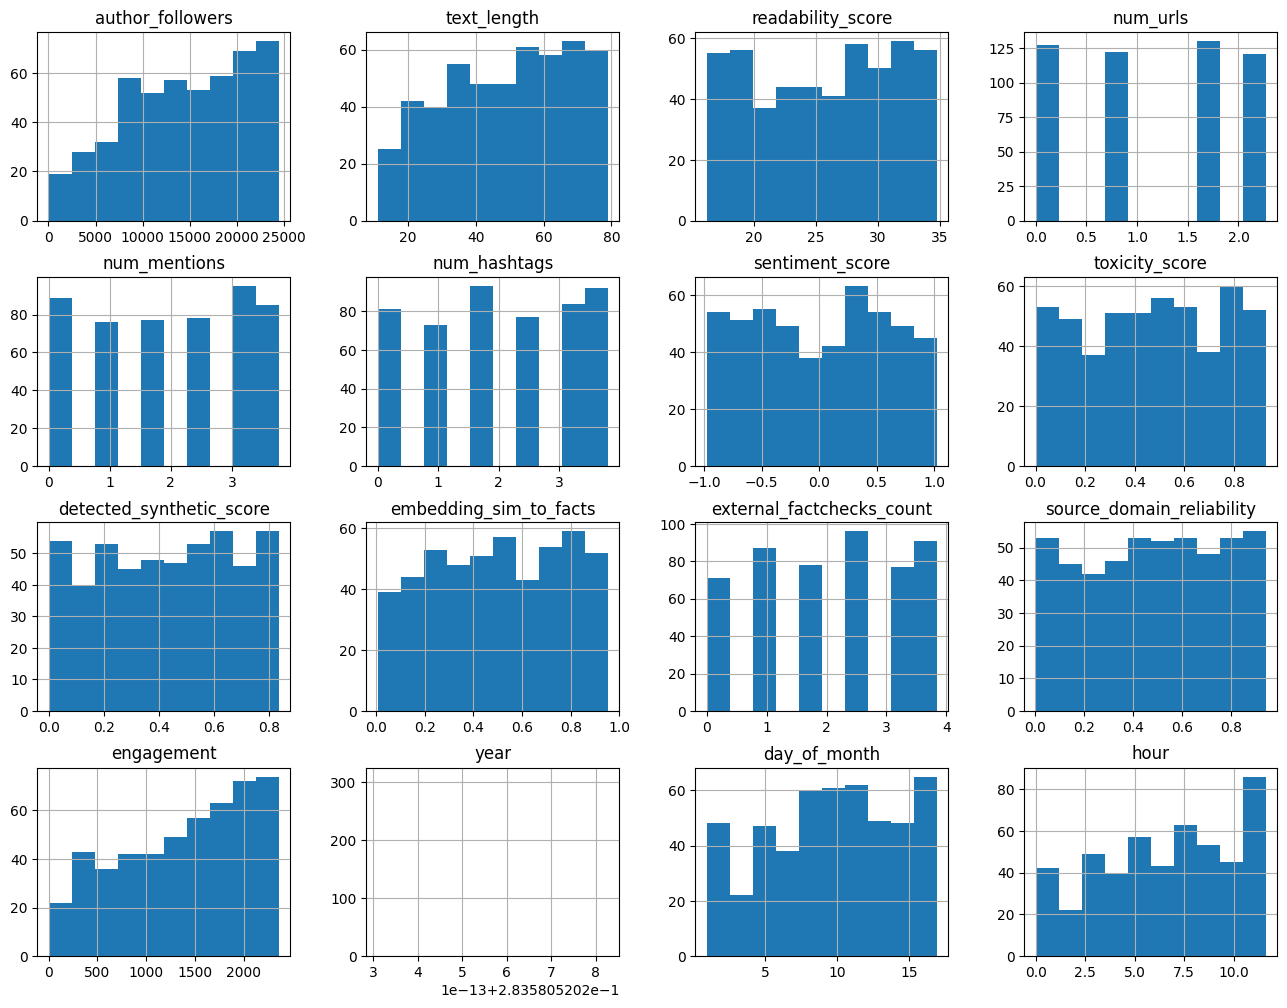

In [691]:
yeo_johnson = PowerTransformer(method = 'yeo-johnson', standardize = False)
df_processed[numeric_cols] = yeo_johnson.fit_transform(df_processed[numeric_cols])
df_processed[numeric_cols].hist(figsize=(16, 12))

### Mixed Naive Bayes

In [ ]:
X = df_processed.drop('is_misinformation', axis = 1)
y = df_processed['is_misinformation']

categ_cols = [i for i in range(X.shape[1]) if X.columns[i] not in numeric_cols]
mnb = MixedNB(categorical_features = categ_cols)

cv = KFold(n_splits = 5, shuffle = True, random_state = 42)
scores = []
for train, test in cv.split(X):
    mnb.fit(X.iloc[train], y.iloc[train])
    scores.append(mnb.score(X.iloc[test], y.iloc[test]))

print(f'Accuracy: {np.mean(scores)}')


Accuracy: 0.46399999999999997


c:\Users\Rohit\.venv\Lib\site-packages\mixed_naive_bayes\mixed_naive_bayes.py:423: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if categorical_features == 'all':
c:\Users\Rohit\.venv\Lib\site-packages\mixed_naive_bayes\mixed_naive_bayes.py:163: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  elif self.categorical_features == 'all':


## Bibliography

- https://machinelearningmastery.com/data-preparation-without-data-leakage/
- https://medium.com/data-science/machine-learning-with-datetime-feature-engineering-predicting-healthcare-appointment-no-shows-5e4ca3a85f96
- https://scikit-learn.org/stable/modules/svm.html
- https://scikit-learn.org/stable/modules/grid_search.html#exhaustive-grid-search